# Harshly Cleaned Price Prediction - XGBoost

Let's start by importing necessary packages.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error, mean_absolute_percentage_error

Now read in the dataframe and prepare it for use with `XGBoost`.

In [2]:
df = pd.read_parquet("../all_car_details_harshly_cleaned.parquet")

## Preparing Data for XGBoost

Let's first drop useless columns.

In [3]:
columns_to_drop = [
    "url",
    "num_images",
    "general_inspection",
    "emission_class",
    "comfort_and_convenience",
    "safety_and_security",
    "entertainment_and_media",
    "extras",
    "paint",
]


df.drop(columns=columns_to_drop, errors="ignore", inplace=True)

Now since XGBoost does not need any scaling, imputing of missing values or turning to tensors, let's start by splitting to ensure no data leakage happens and then split the dataset before applying grouping and OHE.

In [4]:
X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# We'll do this after grouping for high cardinality features
high_card_features = ['make', 'car_title'] # Features to apply grouping
# Other categorical features that don't need grouping but need OHE
# Exclude high_card_features as they will be handled, and ensure no numeric features are accidentally included
other_categorical_features = [col for col in X_train.select_dtypes(include=['object', 'category']).columns if col not in high_card_features]
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()

print(f"High cardinality features to group: {high_card_features}")
print(f"Other categorical features for OHE: {other_categorical_features}")
print(f"Numerical features: {numerical_features}")

High cardinality features to group: ['make', 'car_title']
Other categorical features for OHE: ['seller', 'location', 'body_type', 'used_type', 'drivetrain', 'seats', 'doors', 'full_service_history', 'gearbox', 'gears', 'cylinders', 'fuel_type', 'exterior_colour', 'upholstery_colour', 'upholstery']
Numerical features: ['mileage', 'previous_owner', 'power', 'engine_size', 'empty_weight', 'fuel_consumption', 'co2_emissions', 'age_months']


In [6]:
# --- 5. Grouping High Cardinality Features (Learned from X_train, Applied to X_train & X_test) ---
def get_rare_categories(series, threshold_percentage):
    value_counts_normalized = series.value_counts(normalize=True)
    return value_counts_normalized[value_counts_normalized < threshold_percentage].index

make_threshold_percentage = 0.0001
title_threshold_percentage = 0.00005

# Create copies to avoid SettingWithCopyWarning
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

for feature, threshold in zip(['make', 'car_title'], [make_threshold_percentage, title_threshold_percentage]):
    if feature in X_train_processed.columns:
        print(f"\nProcessing feature: {feature}")
        print(f"Unique values in X_train before grouping: {X_train_processed[feature].nunique()}")
        
        # Learn rare categories from X_train
        rare_categories_train = get_rare_categories(X_train_processed[feature], threshold)
        
        # Apply to X_train
        X_train_processed[feature] = X_train_processed[feature].apply(lambda x: f'Other_{feature}' if x in rare_categories_train else x)
        print(f"Unique values in X_train after grouping: {X_train_processed[feature].nunique()}")
        
        # Apply to X_test (using rare categories learned from X_train)
        if feature in X_test_processed.columns:
            X_test_processed[feature] = X_test_processed[feature].apply(lambda x: f'Other_{feature}' if x in rare_categories_train else x)
            # Handle new categories in X_test not seen in X_train's common categories
            # by mapping them to 'Other_feature' as well
            common_categories_train = X_train_processed[feature].unique()
            X_test_processed[feature] = X_test_processed[feature].apply(lambda x: f'Other_{feature}' if x not in common_categories_train else x)
            print(f"Unique values in X_test after grouping: {X_test_processed[feature].nunique()}")
    else:
        print(f"Feature {feature} not found in X_train.")

# Update the list of categorical features for OHE to include the now-grouped high-cardinality ones
all_categorical_features_for_ohe = high_card_features + other_categorical_features

total_ohe_cols_estimate = 0
print("\n--- Estimating OHE columns ---")
for col in all_categorical_features_for_ohe:
    if col in X_train_processed.columns:
        unique_vals = X_train_processed[col].nunique()
        print(f"Feature '{col}': {unique_vals} unique values (after grouping/filling NaNs)")
        total_ohe_cols_estimate += unique_vals
    else:
        print(f"Feature '{col}' not found in X_train_processed for OHE estimation.")
print(f"Estimated total columns from OHE (if drop=None): {total_ohe_cols_estimate}")
print(f"Numerical features to be passed through: {len(numerical_features)}")
print(f"Grand total estimated features: {total_ohe_cols_estimate + len(numerical_features)}")


Processing feature: make
Unique values in X_train before grouping: 172
Unique values in X_train after grouping: 89
Unique values in X_test after grouping: 89

Processing feature: car_title
Unique values in X_train before grouping: 2018
Unique values in X_train after grouping: 1068
Unique values in X_test after grouping: 1066

--- Estimating OHE columns ---
Feature 'make': 89 unique values (after grouping/filling NaNs)
Feature 'car_title': 1068 unique values (after grouping/filling NaNs)
Feature 'seller': 3 unique values (after grouping/filling NaNs)
Feature 'location': 9 unique values (after grouping/filling NaNs)
Feature 'body_type': 28 unique values (after grouping/filling NaNs)
Feature 'used_type': 6 unique values (after grouping/filling NaNs)
Feature 'drivetrain': 3 unique values (after grouping/filling NaNs)
Feature 'seats': 21 unique values (after grouping/filling NaNs)
Feature 'doors': 8 unique values (after grouping/filling NaNs)
Feature 'full_service_history': 2 unique values

In [7]:
# --- 6. Preprocessing with ColumnTransformer and Pipeline ---
# XGBoost handles NaNs in numerical features. For categorical, OHE needs a strategy.
# We can impute categorical NaNs with a placeholder like 'Missing' before OHE.

# Create a list of transformers
# For OHE, handle_unknown='ignore' will assign all zeros to categories encountered in test but not in train.
# If NaNs are present in categorical columns, OneHotEncoder will raise an error by default.
# We should fill them or use a specific strategy.
# Let's fill NaNs in categorical columns before OHE for simplicity here.
print("Filling NaNs in categorical features with 'Missing_Cat_Value'...")
for col in all_categorical_features_for_ohe:
    if col in X_train_processed.columns:
        X_train_processed[col] = X_train_processed[col].fillna('Missing_Cat_Value')
    if col in X_test_processed.columns:
        X_test_processed[col] = X_test_processed[col].fillna('Missing_Cat_Value')
        
print("NaNs filled in categorical features.")


# Define the ColumnTransformer
# Numerical features will pass through as XGBoost handles their NaNs and doesn't require scaling.
# If you had numerical features needing imputation/scaling, you'd add a ('num', SimpleImputer/StandardScaler, numerical_features)
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, drop=None), all_categorical_features_for_ohe)
    ],
    remainder='passthrough'  # Keep numerical columns not specified in transformers
)
print("Preprocessor created with OneHotEncoder for categorical features and passthrough for numerical features.")

# Fit the preprocessor on X_train_processed and transform both
X_train_final = preprocessor.fit_transform(X_train_processed)
print("Preprocessor fitted and transformed X_train_processed.")
print(f"Type of X_train_final: {type(X_train_final)}") # Should be <class 'scipy.sparse._csr.csr_matrix'> or similar
print(f"Shape of sparse X_train_final: {X_train_final.shape}")

X_test_final = preprocessor.transform(X_test_processed)
print("X_test_processed transformed using the fitted preprocessor.")
print(f"Shape of sparse X_test_final: {X_test_final.shape}")

# Get feature names after OHE for DMatrix or if you want to convert back to DataFrame
# This can be a bit tricky with ColumnTransformer and passthrough.
# Method 1: Get feature names from OneHotEncoder
ohe_feature_names = preprocessor.named_transformers_['ohe'].get_feature_names_out(all_categorical_features_for_ohe)

# Method 2: Construct full list of names
original_cols = X_train_processed.columns.tolist() # Ensure this is defined if not already
passthrough_feature_names = [col for col in original_cols if col not in all_categorical_features_for_ohe]
final_feature_names = list(ohe_feature_names) + passthrough_feature_names
print("Feature names after OHE and passthrough:", final_feature_names)
    
print(f"Number of features after OHE: {len(final_feature_names)}")
# Display some info
# print("\nFirst 5 rows of X_train_final_df:")
# print(X_train_final_df.head())
# print("\nInfo of X_train_final_df:")
# X_train_final_df.info()

Filling NaNs in categorical features with 'Missing_Cat_Value'...
NaNs filled in categorical features.
Preprocessor created with OneHotEncoder for categorical features and passthrough for numerical features.
Preprocessor fitted and transformed X_train_processed.
Type of X_train_final: <class 'scipy.sparse._csr.csr_matrix'>
Shape of sparse X_train_final: (255906, 1346)
X_test_processed transformed using the fitted preprocessor.
Shape of sparse X_test_final: (63977, 1346)
Feature names after OHE and passthrough: ['make_Other_make', 'make_abarth', 'make_aixam', 'make_alfa-romeo', 'make_alpina', 'make_alpine', 'make_aston-martin', 'make_audi', 'make_baic', 'make_byd', 'make_cadillac', 'make_caterham', 'make_cenntro', 'make_chatenet', 'make_chevrolet', 'make_chrysler', 'make_cirelli', 'make_citroen', 'make_corvette', 'make_cupra', 'make_dacia', 'make_daewoo', 'make_daihatsu', 'make_dfsk', 'make_dodge', 'make_dr-automobiles', 'make_ds-automobiles', 'make_emc', 'make_evo', 'make_fiat', 'make_f

In [8]:
# --- 7. Prepare DMatrix for XGBoost ---
# XGBoost DMatrix can directly handle scipy sparse matrices
dtrain = xgb.DMatrix(X_train_final, label=y_train, feature_names=final_feature_names)
dtest = xgb.DMatrix(X_test_final, label=y_test, feature_names=final_feature_names)

print("\nDMatrix created successfully from sparse data.")


DMatrix created successfully from sparse data.


## Train XGBoost

In [9]:
# --- 8. Train a Baseline XGBoost Model ---
print("--- Training Baseline XGBoost Model ---")

# Define baseline parameters
# These are just starting points
params = {
    'objective': 'reg:squarederror',  # For regression tasks, predicts the squared error
    'eval_metric': ['rmse', 'mae'],   # Evaluation metrics: Root Mean Squared Error, Mean Absolute Error
    'eta': 0.1,                       # Learning rate (alias: learning_rate)
    'max_depth': 6,                   # Maximum depth of a tree
    'subsample': 0.8,                 # Subsample ratio of the training instances
    'colsample_bytree': 0.8,          # Subsample ratio of columns when constructing each tree
    'seed': 42                        # For reproducibility
}

num_boost_round = 100  # Number of boosting rounds (trees to build)

# Set up a watchlist to monitor performance on the test set during training
watchlist = [(dtrain, 'train'), (dtest, 'eval')]

print(f"Starting training with {num_boost_round} rounds...")
bst_model = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=watchlist,
    early_stopping_rounds=10,  # Stop if performance on eval set doesn't improve for 10 rounds
    verbose_eval=10            # Print evaluation metrics every 10 rounds
)

print("Baseline model training complete.")

--- Training Baseline XGBoost Model ---
Starting training with 100 rounds...
[0]	train-rmse:12507.85150	train-mae:10062.43656	eval-rmse:12524.54475	eval-mae:10078.73485
[10]	train-rmse:6914.34112	train-mae:5167.14485	eval-rmse:6924.38694	eval-mae:5178.31143
[20]	train-rmse:5187.75611	train-mae:3600.35730	eval-rmse:5200.79886	eval-mae:3608.54151
[30]	train-rmse:4650.68797	train-mae:3107.50718	eval-rmse:4676.72760	eval-mae:3120.79843
[40]	train-rmse:4409.09666	train-mae:2900.73650	eval-rmse:4451.18442	eval-mae:2919.81499
[50]	train-rmse:4283.77817	train-mae:2797.84704	eval-rmse:4335.15394	eval-mae:2821.02062
[60]	train-rmse:4206.97097	train-mae:2739.28111	eval-rmse:4265.20060	eval-mae:2765.55269
[70]	train-rmse:4149.81416	train-mae:2694.37472	eval-rmse:4213.85877	eval-mae:2721.88999
[80]	train-rmse:4098.53272	train-mae:2659.66374	eval-rmse:4171.38727	eval-mae:2690.07020
[90]	train-rmse:4043.42988	train-mae:2620.79734	eval-rmse:4123.06318	eval-mae:2653.81140
[99]	train-rmse:4007.68678	tra

In [10]:
# --- 9. Make Predictions and Evaluate Baseline Model ---
print("\n--- Evaluating Baseline Model ---")
y_pred_baseline = bst_model.predict(dtest)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print(f"Baseline Model - Test Set Performance:")
print(f"  Mean Absolute Error (MAE): {mae_baseline:.4f}")
print(f"  R-squared (R2): {r2_baseline:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_baseline:.4f}")
print(f"  Mean Absolute Percentage Error (MAPE): {mean_absolute_percentage_error(y_test, y_pred_baseline) * 100:.2f}%")

# You can also access the best score and iteration if early stopping occurred
print(f"Best MAE on eval set during training: {bst_model.best_score:.4f} at iteration {bst_model.best_iteration+1}")


--- Evaluating Baseline Model ---
Baseline Model - Test Set Performance:
  Mean Absolute Error (MAE): 2630.1318
  R-squared (R2): 0.9096
  Root Mean Squared Error (RMSE): 4090.5164
  Mean Absolute Percentage Error (MAPE): 24.59%
Best MAE on eval set during training: 2630.1318 at iteration 100



--- Feature Importance (Baseline Model) ---


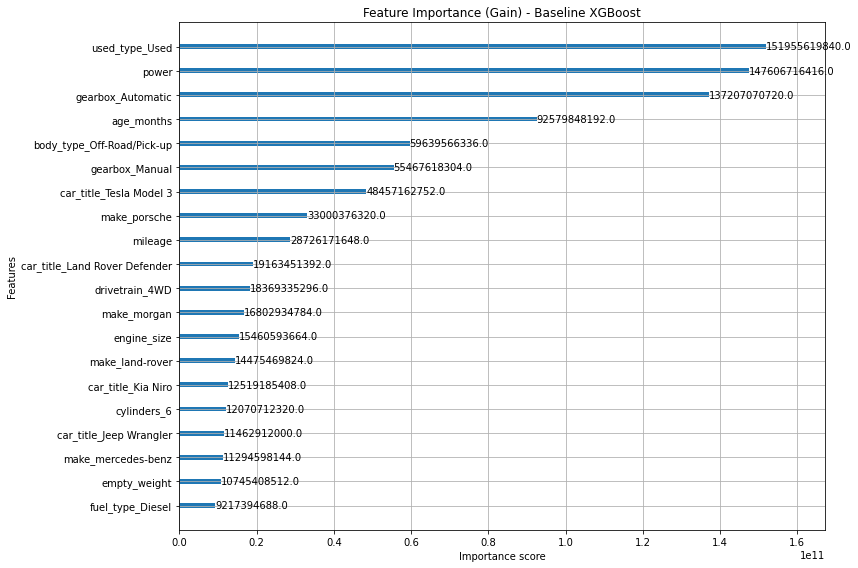

Top 10 features by gain: [('used_type_Used', 151955619840.0), ('power', 147606716416.0), ('gearbox_Automatic', 137207070720.0), ('age_months', 92579848192.0), ('body_type_Off-Road/Pick-up', 59639566336.0), ('gearbox_Manual', 55467618304.0), ('car_title_Tesla Model 3', 48457162752.0), ('make_porsche', 33000376320.0), ('mileage', 28726171648.0), ('car_title_Land Rover Defender', 19163451392.0)]


In [11]:
# --- 10. Feature Importance (Optional but useful) ---
print("\n--- Feature Importance (Baseline Model) ---")
# Plot feature importance
fig, ax = plt.subplots(figsize=(12, 8)) # Adjust height based on num features
xgb.plot_importance(bst_model, ax=ax, max_num_features=20, importance_type='gain') # Show top 20 features by gain
plt.title("Feature Importance (Gain) - Baseline XGBoost")
plt.tight_layout()
plt.show()

# You can also get importance as a dictionary
# importance_types: 'weight', 'gain', 'cover', 'total_gain', 'total_cover'
# 'gain' is often a good default for feature contribution.
feature_importance_gain = bst_model.get_score(importance_type='gain')
print("Top 10 features by gain:", sorted(feature_importance_gain.items(), key=lambda item: item[1], reverse=True)[:10])

It seems like unsurprisingly the make and car_title were the most significant predictors by feature importance.

## Hyperparameter Tuning

In [12]:
# Example using RandomizedSearchCV (conceptual)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    objective='reg:squarederror',
    seed=42,
    eval_metric='mae',
    early_stopping_rounds=10
)

param_dist = {
    'n_estimators': [100, 200, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    xgb_reg,
    param_distributions=param_dist,
    n_iter=15,  # Number of parameter settings that are sampled
    # Use a score that can be maximized (hence negative MAE)
    scoring='neg_mean_absolute_error',
    cv=2,      # 2-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

print("Attempting to start RandomizedSearchCV.fit()...") # Add this line
# Note: RandomizedSearchCV expects dense data or a compatible sparse format.
# X_train_final (if sparse) should work.
random_search.fit(X_train_final, y_train,
                  eval_set=[(X_test_final, y_test)],
                  verbose=True)
print("Best parameters found: ", random_search.best_params_)
print("Best MAE found: ", -random_search.best_score_)
best_xgb_model = random_search.best_estimator_

Attempting to start RandomizedSearchCV.fit()...
Fitting 2 folds for each of 15 candidates, totalling 30 fits
[0]	validation_0-mae:10061.00378
[1]	validation_0-mae:9251.35607
[2]	validation_0-mae:8488.30287
[3]	validation_0-mae:7937.86165
[4]	validation_0-mae:7321.29401
[5]	validation_0-mae:6779.91923
[6]	validation_0-mae:6301.23395
[7]	validation_0-mae:5879.78291
[8]	validation_0-mae:5521.39204
[9]	validation_0-mae:5192.42341
[10]	validation_0-mae:4907.12244
[11]	validation_0-mae:4645.16749
[12]	validation_0-mae:4419.76825
[13]	validation_0-mae:4222.69508
[14]	validation_0-mae:4053.58725
[15]	validation_0-mae:3903.27163
[16]	validation_0-mae:3769.94442
[17]	validation_0-mae:3653.85597
[18]	validation_0-mae:3552.70063
[19]	validation_0-mae:3463.39760
[20]	validation_0-mae:3379.73463
[21]	validation_0-mae:3307.51644
[22]	validation_0-mae:3242.51694
[23]	validation_0-mae:3187.59653
[24]	validation_0-mae:3134.48567
[25]	validation_0-mae:3088.60863
[26]	validation_0-mae:3045.81905
[27]	vali

The best parameters from these were seemingly always the more fine grained detailed ones, let's try and give it more max-depth. Let's see 20.

In [13]:
# Best parameters found:  {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
# Best MAE found:  2195.843
best_params = {
    'subsample': 0.7,
    'n_estimators': 500,
    'min_child_weight': 1,
    'max_depth': 20,
    'learning_rate': 0.1,
    'colsample_bytree': 0.9
}

# Initialize and train the final model
final_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=15,
    **best_params  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting final model training with early stopping and metric tracking...")
final_model.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")

# Retrieve the evaluation results
results = final_model.evals_result()

Starting final model training with early stopping and metric tracking...
[0]	validation_0-mae:9954.39372	validation_1-mae:9996.92902
[1]	validation_0-mae:9018.74770	validation_1-mae:9083.38863
[2]	validation_0-mae:8175.63742	validation_1-mae:8263.95845
[3]	validation_0-mae:7418.43410	validation_1-mae:7529.42330
[4]	validation_0-mae:6745.00857	validation_1-mae:6887.99894
[5]	validation_0-mae:6129.63387	validation_1-mae:6300.79056
[6]	validation_0-mae:5577.29053	validation_1-mae:5776.69188
[7]	validation_0-mae:5097.77906	validation_1-mae:5322.28461
[8]	validation_0-mae:4654.72559	validation_1-mae:4910.67740
[9]	validation_0-mae:4248.52951	validation_1-mae:4536.28987
[10]	validation_0-mae:3883.98196	validation_1-mae:4204.82671
[11]	validation_0-mae:3559.49364	validation_1-mae:3912.96168
[12]	validation_0-mae:3280.79601	validation_1-mae:3667.66475
[13]	validation_0-mae:3017.14073	validation_1-mae:3438.01332
[14]	validation_0-mae:2780.94456	validation_1-mae:3237.34033
[15]	validation_0-mae:

## Analyze Results

Let's plot the MAEs to see if it is worth to train for more rounds.

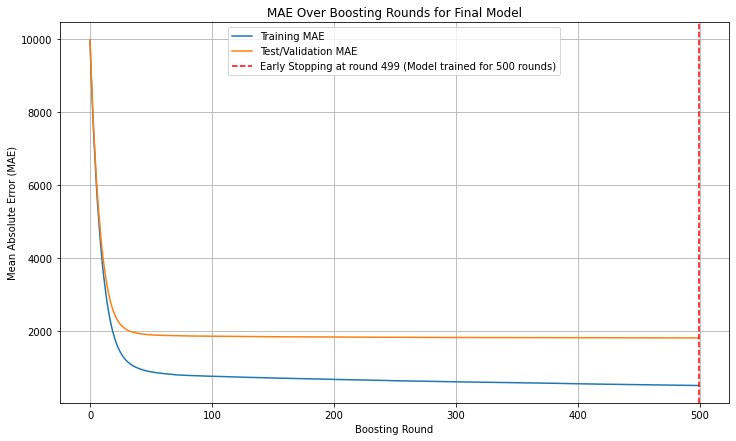

The model was trained for 500 rounds.
The best MAE achieved on the test set during training was: 1806.83


In [14]:
# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history = results['validation_0']['mae']
test_mae_history = results['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history, label='Training MAE')
plt.plot(test_mae_history, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds = final_model.best_iteration + 1
plt.axvline(final_model.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {final_model.best_iteration} (Model trained for {actual_rounds} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds} rounds.")
print(f"The best MAE achieved on the test set during training was: {final_model.best_score:.2f}")

In [23]:
# Predictions
y_train_pred = final_model.predict(X_train_final)
y_test_pred = final_model.predict(X_test_final)

# Training set metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_mape = mean_absolute_percentage_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

# Test set metrics
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae:.4f}, MSE: {train_mse:.4f}, R²: {train_r2:.4f}, MAPE: {train_mape * 100:.4f}%")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae:.4f}, MSE: {test_mse:.4f}, R²: {test_r2:.4f}, MAPE: {test_mape * 100:.4f}%")

# Residuals
residuals = y_test - y_test_pred

# plt.figure(figsize=(10, 6))
# plt.scatter(y_test_pred, residuals, alpha=0.5, edgecolors="k")
# plt.axhline(y=0, color='red', linestyle='--', lw=2)
# plt.xlabel("Predicted Values")
# plt.ylabel("Residuals (Actual - Predicted)")
# plt.title("Residuals Plot - XGBoost")

Training Metrics:
MAE: 500.7276, MSE: 522615.9210, R²: 0.9972, MAPE: 6.4371%

Test Metrics:
MAE: 1806.8305, MSE: 10388687.9100, R²: 0.9439, MAPE: 16.6321%


We can see that by 500 rounds the model is almost starting to overfit as the Training MAE and Test MAE diverge, the Test one flattens out more. Let's for good measure try and run it until 1000 with no max depth.

In [18]:
best_params_1000 = {
    'subsample': 0.7,
    'n_estimators': 1500,
    'min_child_weight': 1,
    'max_depth': 25,
    'learning_rate': 0.1,
    'colsample_bytree': 0.9
}

# Initialize and train the final model
final_model_1000 = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    early_stopping_rounds=15,
    **best_params_1000  # Unpack the best parameters
)

# Define the evaluation sets. It's good practice to monitor both.
# XGBoost will refer to them as 'validation_0' and 'validation_1' in the results.
evaluation_set_for_final_training_1000 = [(X_train_final, y_train), (X_test_final, y_test)]

print("Starting final model training with early stopping and metric tracking...")
final_model_1000.fit(
    X_train_final, y_train,
    eval_set=evaluation_set_for_final_training_1000,
    verbose=True  # Shows MAE at each round or at intervals
)
print("Final model training completed.")


Starting final model training with early stopping and metric tracking...
[0]	validation_0-mae:9949.68147	validation_1-mae:9995.93049
[1]	validation_0-mae:9010.52512	validation_1-mae:9081.88329
[2]	validation_0-mae:8162.44822	validation_1-mae:8261.10106
[3]	validation_0-mae:7399.87903	validation_1-mae:7526.60963
[4]	validation_0-mae:6719.71381	validation_1-mae:6883.12085
[5]	validation_0-mae:6097.61003	validation_1-mae:6293.78474
[6]	validation_0-mae:5536.81830	validation_1-mae:5766.50497
[7]	validation_0-mae:5046.92222	validation_1-mae:5308.40142
[8]	validation_0-mae:4596.22120	validation_1-mae:4895.73947
[9]	validation_0-mae:4184.15475	validation_1-mae:4521.44725
[10]	validation_0-mae:3811.80373	validation_1-mae:4188.24427
[11]	validation_0-mae:3477.13097	validation_1-mae:3893.48829
[12]	validation_0-mae:3186.32769	validation_1-mae:3644.60943
[13]	validation_0-mae:2914.49122	validation_1-mae:3415.04475
[14]	validation_0-mae:2669.25199	validation_1-mae:3213.61749
[15]	validation_0-mae:

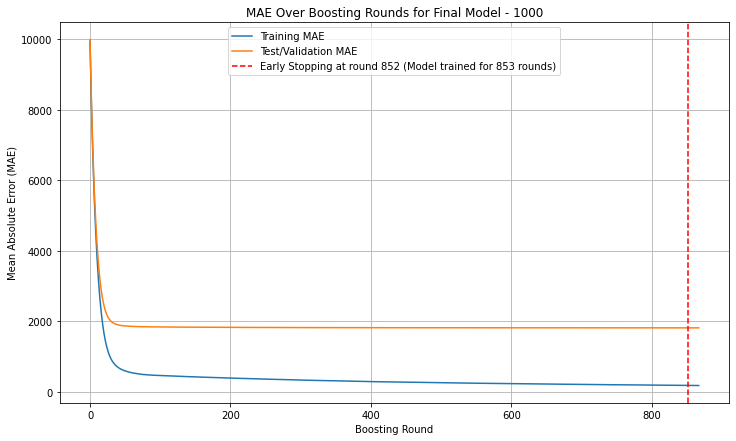

The model was trained for 853 rounds.
The best MAE achieved on the test set during training was: 1817.00


In [19]:
# Retrieve the evaluation results
results_1000 = final_model_1000.evals_result()

# Extract MAE history
# 'validation_0' corresponds to the first item in eval_set (X_train_final, y_train)
# 'validation_1' corresponds to the second item in eval_set (X_test_final, y_test)
train_mae_history_1000 = results_1000['validation_0']['mae']
test_mae_history_1000 = results_1000['validation_1']['mae']

plt.figure(figsize=(12, 7))
plt.plot(train_mae_history_1000, label='Training MAE')
plt.plot(test_mae_history_1000, label='Test/Validation MAE')

# The actual number of boosting rounds run (due to early stopping)
# final_model.best_iteration is the round with the best score (0-indexed)
actual_rounds_1000 = final_model_1000.best_iteration + 1
plt.axvline(final_model_1000.best_iteration, color='r', linestyle='--', 
            label=f'Early Stopping at round {final_model_1000.best_iteration} (Model trained for {actual_rounds_1000} rounds)')

plt.title('MAE Over Boosting Rounds for Final Model - 1000')
plt.xlabel('Boosting Round')
plt.ylabel('Mean Absolute Error (MAE)')
plt.legend()
plt.grid(True)
plt.show()

print(f"The model was trained for {actual_rounds_1000} rounds.")
print(f"The best MAE achieved on the test set during training was: {final_model_1000.best_score:.2f}")

In [20]:
# Predictions
y_train_pred_1000 = final_model_1000.predict(X_train_final)
y_test_pred_1000 = final_model_1000.predict(X_test_final)

# Training set metrics
train_mae_1000 = mean_absolute_error(y_train, y_train_pred_1000)
train_mse_1000 = mean_squared_error(y_train, y_train_pred_1000)  # MSE added
train_r2_1000 = r2_score(y_train, y_train_pred_1000)

# Test set metrics
test_mae_1000 = mean_absolute_error(y_test, y_test_pred_1000)
test_mse_1000 = mean_squared_error(y_test, y_test_pred_1000)     # MSE added
test_r2_1000 = r2_score(y_test, y_test_pred_1000)

# Print results with MSE
print(f"Training Metrics:")
print(f"MAE: {train_mae_1000:.4f}, MSE: {train_mse_1000:.4f}, R²: {train_r2_1000:.4f}")
print(f"\nTest Metrics:")
print(f"MAE: {test_mae_1000:.4f}, MSE: {test_mse_1000:.4f}, R²: {test_r2_1000:.4f}")

Training Metrics:
MAE: 185.2807, MSE: 83680.9472, R²: 0.9995

Test Metrics:
MAE: 1816.9981, MSE: 10566161.9315, R²: 0.9429


We can see that this managed to learn the train set almost perfectly, however it has overfit and the actual test statistic were no better than that of the simpler model.

Thus, I have chosen to use the simpler model as our best.

## Plots

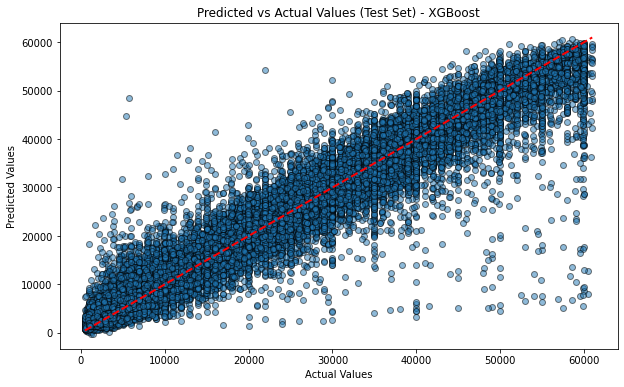

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, edgecolors="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)  # Diagonal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual Values (Test Set) - XGBoost")
plt.show()

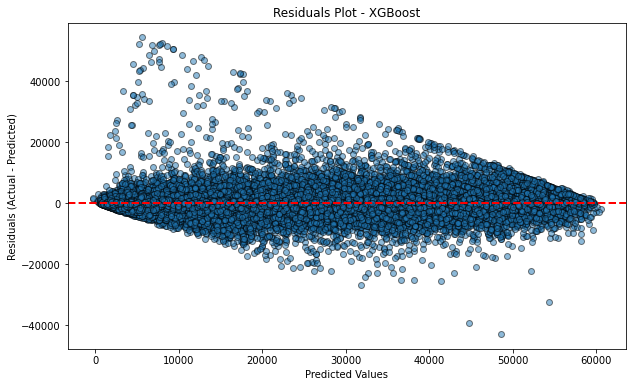

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.5, edgecolors="k")
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot - XGBoost")
plt.show()

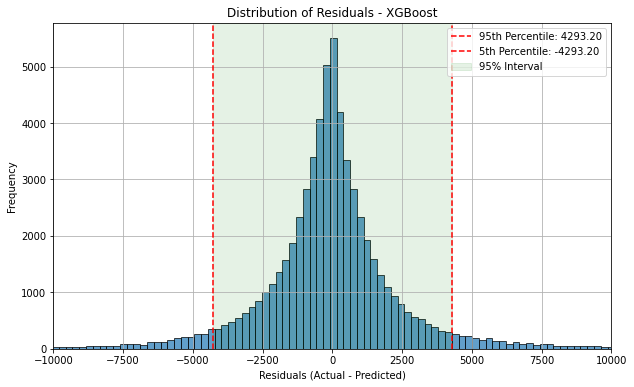

In [32]:
# Calculate the 95th percentile of the residuals
percentile_95 = np.percentile(residuals, 95)

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=400, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals - XGBoost')

# Add vertical lines for the 95th percentile
plt.axvline(x=percentile_95, color='r', linestyle='--', label=f'95th Percentile: {percentile_95:.2f}')
plt.axvline(x=-percentile_95, color='r', linestyle='--', label=f'5th Percentile: {-percentile_95:.2f}')

# Optional: Add a shaded region for the 95% interval
plt.axvspan(-percentile_95, percentile_95, color='green', alpha=0.1, label='95% Interval')

plt.grid(True)
plt.xlim(-10000, 10000)
plt.legend()
plt.show()

### Feature Importance

<Figure size 720x576 with 0 Axes>

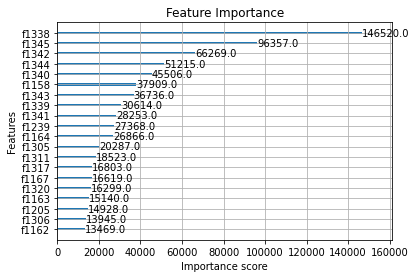

In [31]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(final_model, max_num_features=20)
plt.title("Feature Importance")
plt.show()